# Case 4: Heat Diffusion Equation with Source Term

## Governing Equation

$$
\frac{\partial y}{\partial t}
=
\frac{\partial^2 y}{\partial x^2}
+1
$$

## Boundary Conditions

Left Boundary:

$$
y(0)=1
$$

Right Boundary:

$$
\frac{dy}{dx}(1)=0
$$

## Initial Condition

$$
y(x,0)=\sin(\pi x)
$$

## Objective

To study the transient and steady-state behaviour of the one-dimensional heat diffusion equation with a uniform source term using the finite volume method implemented in FiPy.

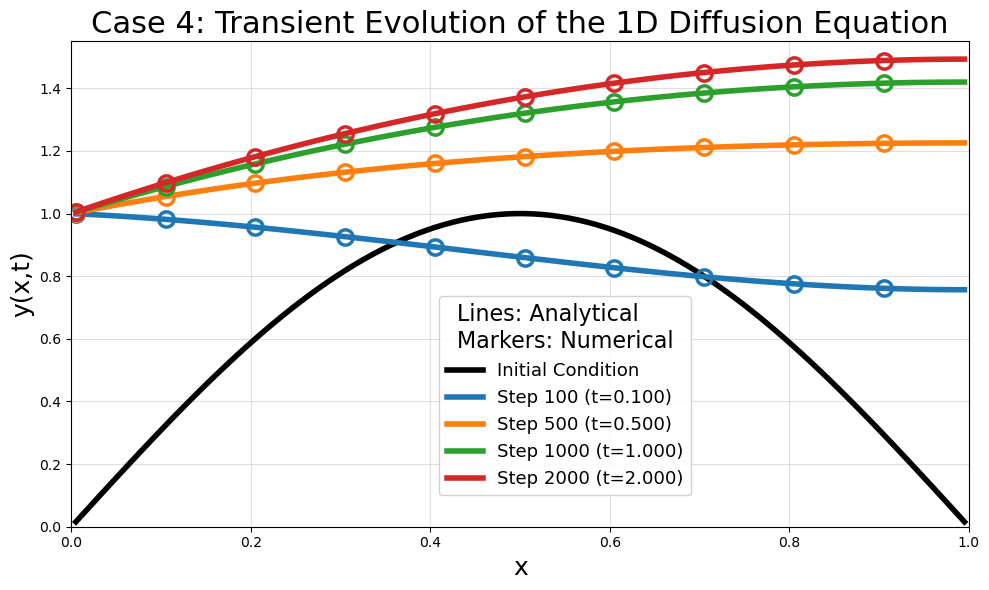

In [8]:
# =====================================================
# CASE 4 : TRANSIENT EVOLUTION
# NUMERICAL vs ANALYTICAL STYLE PLOT
# =====================================================

from fipy import *
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# DOMAIN
# =====================================================

L = 1.0
nx = 100
dx = L / nx

mesh = Grid1D(nx=nx, dx=dx)
x = np.array(mesh.cellCenters[0])

# =====================================================
# INITIAL CONDITION
# =====================================================

phi = CellVariable(
    name="Temperature",
    mesh=mesh,
    value=np.sin(np.pi * x)
)

initial_condition = phi.value.copy()

# =====================================================
# BOUNDARY CONDITIONS
# =====================================================

# Dirichlet BC
phi.constrain(1.0, mesh.facesLeft)

# Neumann BC
phi.faceGrad.constrain([0.0], mesh.facesRight)

# =====================================================
# GOVERNING EQUATION
# =====================================================

eq = (
    TransientTerm()
    ==
    DiffusionTerm(coeff=1.0)
    + 1.0
)

# =====================================================
# TRANSIENT SOLUTION
# =====================================================

dt = 1e-3

times = [0.1, 0.5, 1.0, 2.0]

steps_required = [int(t / dt) for t in times]

labels = [
    "Step 100 (t=0.100)",
    "Step 500 (t=0.500)",
    "Step 1000 (t=1.000)",
    "Step 2000 (t=2.000)"
]

solutions = []

current_step = 0

for target_step in steps_required:

    while current_step < target_step:
        eq.solve(var=phi, dt=dt)
        current_step += 1

    solutions.append(phi.value.copy())

# =====================================================
# PLOT
# =====================================================

plt.figure(figsize=(10, 6))

# Initial Condition

plt.plot(
    x,
    initial_condition,
    'k-',
    linewidth=4,
    label='Initial Condition'
)

colors = ['C0', 'C1', 'C2', 'C3']

for sol, label, color in zip(solutions, labels, colors):

    # Line

    plt.plot(
        x,
        sol,
        color=color,
        linewidth=4,
        label=label
    )

    # Markers

    plt.plot(
        x[::10],
        sol[::10],
        linestyle='None',
        marker='o',
        markersize=11,
        markerfacecolor='none',
        markeredgewidth=2.5,
        color=color
    )

# =====================================================
# FORMATTING
# =====================================================

plt.xlabel('x', fontsize=18)
plt.ylabel('y(x,t)', fontsize=18)

plt.title(
    'Case 4: Transient Evolution of the 1D Diffusion Equation',
    fontsize=22
)

plt.xlim(0, 1)
plt.ylim(0, 1.55)

plt.legend(
    title='Lines: Analytical\nMarkers: Numerical',
    loc='center',
    bbox_to_anchor=(0.55, 0.27),
    fontsize=13,
    title_fontsize=16,
    framealpha=0.9
)

plt.grid(True, alpha=0.4)

plt.tight_layout()

plt.savefig(
    'Case4_Transient_Evolution.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Observation

The transient temperature profiles evolve from the initial sinusoidal distribution toward the steady-state solution.

The presence of the uniform source term continuously adds heat to the domain, causing the temperature to increase with time. The left boundary remains fixed at y(0)=1, while the zero-gradient condition at x=1 produces a smooth flattening of the profile near the right boundary.

As time progresses, the solution approaches the analytical steady-state profile:

$$
y=1+x-\frac{x^2}{2}
$$

which is a downward-opening parabolic distribution.

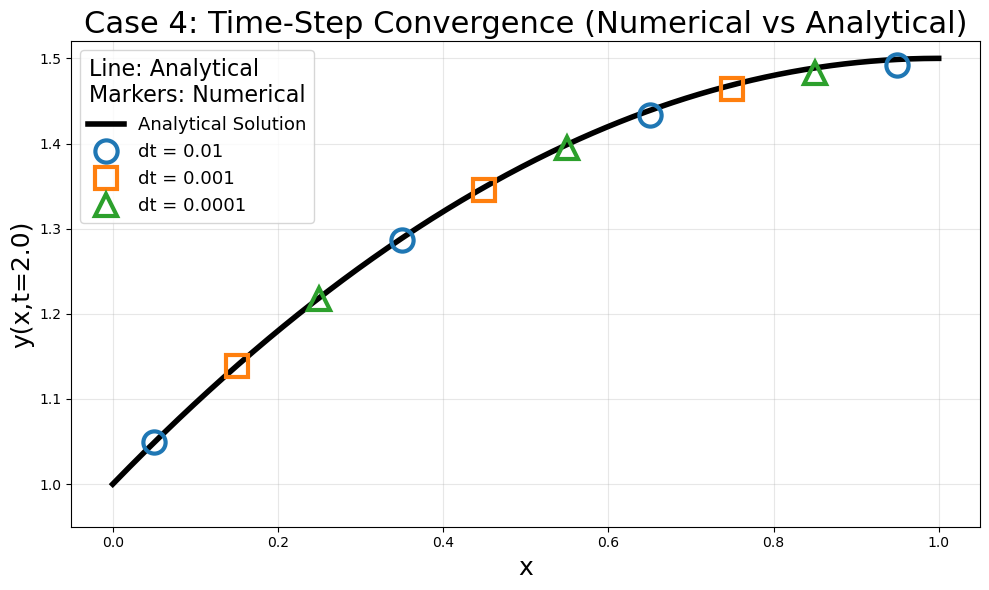

In [15]:
# =====================================================
# CASE 4 : TIME-STEP CONVERGENCE
# NUMERICAL vs ANALYTICAL
# =====================================================

from fipy import *
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# DOMAIN
# =====================================================

L = 1.0
nx = 10
dx = L / nx

mesh = Grid1D(nx=nx, dx=dx)
x = np.array(mesh.cellCenters[0])

# =====================================================
# TIME STEP VALUES
# =====================================================

dt_values = [1e-2, 1e-3, 1e-4]

solutions = []

# =====================================================
# SOLVE FOR EACH TIME STEP
# =====================================================

for dt in dt_values:

    phi = CellVariable(
        name="Temperature",
        mesh=mesh,
        value=np.sin(np.pi * x)
    )

    # Boundary Conditions

    phi.constrain(1.0, mesh.facesLeft)
    phi.faceGrad.constrain([0.0], mesh.facesRight)

    # Governing Equation

    eq = (
        TransientTerm()
        ==
        DiffusionTerm(coeff=1.0)
        + 1.0
    )

    final_time = 2.0
    steps = int(final_time / dt)

    for step in range(steps):
        eq.solve(var=phi, dt=dt)

    solutions.append(phi.value.copy())

# =====================================================
# ANALYTICAL SOLUTION
# =====================================================

x_analytical = np.linspace(0, L, 500)

analytical = (
    -0.5 * x_analytical**2
    + x_analytical
    + 1.0
)

# =====================================================
# PLOT
# =====================================================

plt.figure(figsize=(10,6))

# Analytical Line

plt.plot(
    x_analytical,
    analytical,
    'k-',
    linewidth=4,
    label='Analytical Solution'
)

# =====================================================
# NUMERICAL MARKERS
# =====================================================

# Blue circles
plt.plot(
    x[0::3],
    solutions[0][0::3],
    linestyle='None',
    marker='o',
    markersize=16,
    markerfacecolor='none',
    markeredgewidth=3,
    label='dt = 0.01'
)

# Orange squares
plt.plot(
    x[1::3],
    solutions[1][1::3],
    linestyle='None',
    marker='s',
    markersize=16,
    markerfacecolor='none',
    markeredgewidth=3,
    label='dt = 0.001'
)

# Green triangles
plt.plot(
    x[2::3],
    solutions[2][2::3],
    linestyle='None',
    marker='^',
    markersize=16,
    markerfacecolor='none',
    markeredgewidth=3,
    label='dt = 0.0001'
)

# =====================================================
# FORMATTING
# =====================================================

plt.xlabel('x', fontsize=18)
plt.ylabel('y(x,t=2.0)', fontsize=18)

plt.title(
    'Case 4: Time-Step Convergence (Numerical vs Analytical)',
    fontsize=22
)

plt.xlim(-0.05, 1.05)
plt.ylim(0.95, 1.52)

plt.legend(
    title='Line: Analytical\nMarkers: Numerical',
    fontsize=13,
    title_fontsize=16,
    loc='upper left'
)

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    'Case4_TimeStep_Convergence.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

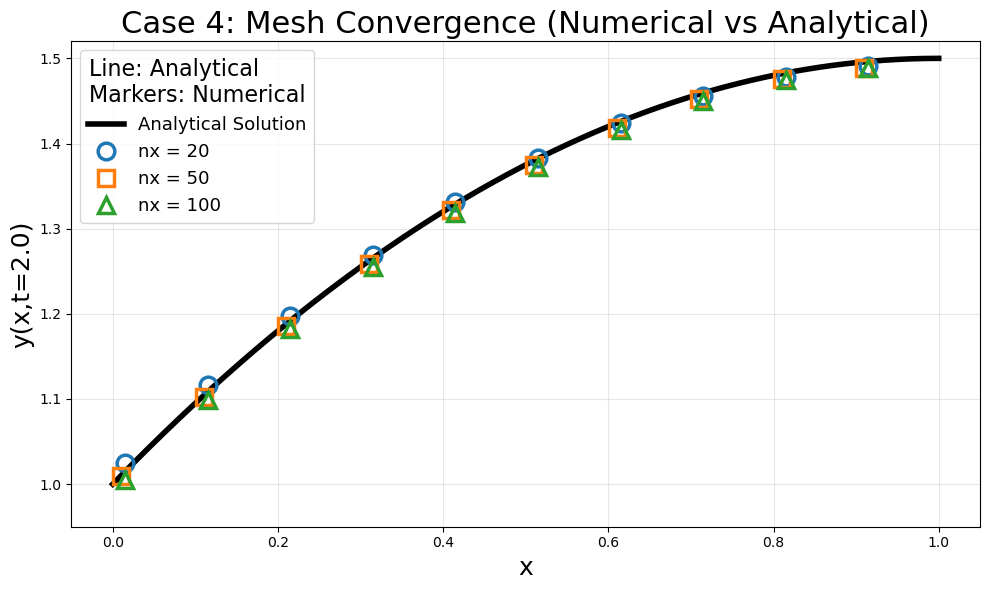

In [20]:
# =====================================================
# CASE 4 : MESH CONVERGENCE
# NUMERICAL vs ANALYTICAL
# =====================================================

from fipy import *
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# DOMAIN
# =====================================================

L = 1.0

nx_values = [20, 50, 100]

solutions = []
x_coordinates = []

# =====================================================
# SOLVE
# =====================================================

for nx in nx_values:

    dx = L / nx

    mesh = Grid1D(nx=nx, dx=dx)
    x = np.array(mesh.cellCenters[0])

    phi = CellVariable(
        name="Temperature",
        mesh=mesh,
        value=np.sin(np.pi * x)
    )

    # Boundary Conditions

    phi.constrain(1.0, mesh.facesLeft)
    phi.faceGrad.constrain([0.0], mesh.facesRight)

    # Governing Equation

    eq = (
        TransientTerm()
        ==
        DiffusionTerm(coeff=1.0)
        + 1.0
    )

    dt = 1e-3
    final_time = 2.0
    steps = int(final_time / dt)

    for step in range(steps):
        eq.solve(var=phi, dt=dt)

    solutions.append(phi.value.copy())
    x_coordinates.append(x)

# =====================================================
# ANALYTICAL SOLUTION
# =====================================================

x_analytical = np.linspace(0, L, 500)

analytical = (
    -0.5 * x_analytical**2
    + x_analytical
    + 1.0
)

# =====================================================
# PLOT
# =====================================================

plt.figure(figsize=(10, 6))

# Analytical Solution

plt.plot(
    x_analytical,
    analytical,
    'k-',
    linewidth=4,
    label='Analytical Solution'
)

markers = ['o', 's', '^']

# Small offsets for visibility
offsets = [-0.01, 0.0, 0.01]

for x, sol, nx, marker, offset in zip(
    x_coordinates,
    solutions,
    nx_values,
    markers,
    offsets
):

    skip = max(1, len(x) // 10)

    plt.plot(
        x[::skip] + offset,
        sol[::skip],
        linestyle='None',
        marker=marker,
        markersize=12,
        markerfacecolor='none',
        markeredgewidth=2.5,
        label=f'nx = {nx}'
    )

# =====================================================
# FORMATTING
# =====================================================

plt.xlabel('x', fontsize=18)
plt.ylabel('y(x,t=2.0)', fontsize=18)

plt.title(
    'Case 4: Mesh Convergence (Numerical vs Analytical)',
    fontsize=22
)

plt.xlim(-0.05, 1.05)
plt.ylim(0.95, 1.52)

plt.legend(
    title='Line: Analytical\nMarkers: Numerical',
    fontsize=13,
    title_fontsize=16,
    loc='upper left'
)

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    'Case4_Mesh_Convergence.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# Steady-State Analysis

The governing equation was solved for a sufficiently large simulation time to obtain the steady-state temperature distribution.

The numerical steady-state solution is expected to approach the analytical solution:

$$
y = 1 + x - \frac{x^2}{2}
$$

which represents a downward-opening parabolic temperature profile.


========== STEADY-STATE ANALYSIS ==========
Minimum Value = 1.0049999999998591
Maximum Value = 1.499999999981949


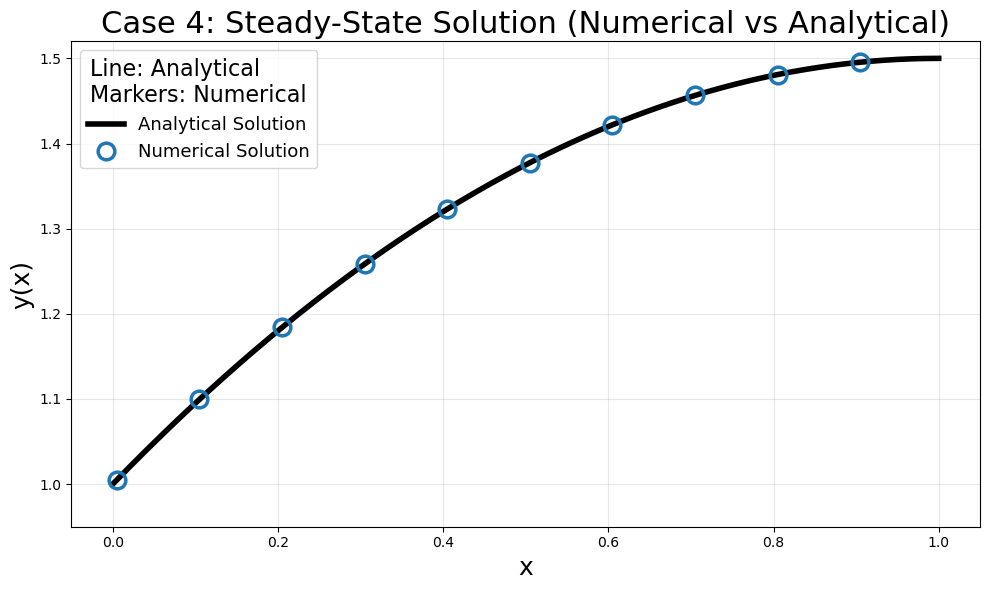

In [21]:
# =====================================================
# CASE 4 : STEADY-STATE ANALYSIS
# NUMERICAL vs ANALYTICAL
# =====================================================

from fipy import *
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# DOMAIN
# =====================================================

L = 1.0
nx = 100
dx = L / nx

mesh = Grid1D(nx=nx, dx=dx)
x = np.array(mesh.cellCenters[0])

# =====================================================
# INITIAL CONDITION
# =====================================================

phi = CellVariable(
    name="Temperature",
    mesh=mesh,
    value=np.sin(np.pi * x)
)

# =====================================================
# BOUNDARY CONDITIONS
# =====================================================

phi.constrain(1.0, mesh.facesLeft)
phi.faceGrad.constrain([0.0], mesh.facesRight)

# =====================================================
# GOVERNING EQUATION
# =====================================================

eq = (
    TransientTerm()
    ==
    DiffusionTerm(coeff=1.0)
    + 1.0
)

# =====================================================
# TIME INTEGRATION
# =====================================================

dt = 1e-3
final_time = 10.0
steps = int(final_time / dt)

for step in range(steps):
    eq.solve(var=phi, dt=dt)

numerical = np.array(phi.value)

# =====================================================
# ANALYTICAL SOLUTION
# =====================================================

x_analytical = np.linspace(0, L, 500)

analytical = (
    -0.5 * x_analytical**2
    + x_analytical
    + 1.0
)

# =====================================================
# RESULTS
# =====================================================

print("\n========== STEADY-STATE ANALYSIS ==========")
print("Minimum Value =", np.min(numerical))
print("Maximum Value =", np.max(numerical))

# =====================================================
# PLOT
# =====================================================

plt.figure(figsize=(10,6))

# Analytical Line

plt.plot(
    x_analytical,
    analytical,
    'k-',
    linewidth=4,
    label='Analytical Solution'
)

# Numerical Markers

plt.plot(
    x[::10],
    numerical[::10],
    linestyle='None',
    marker='o',
    markersize=12,
    markerfacecolor='none',
    markeredgewidth=2.5,
    label='Numerical Solution'
)

plt.xlabel('x', fontsize=18)
plt.ylabel('y(x)', fontsize=18)

plt.title(
    'Case 4: Steady-State Solution (Numerical vs Analytical)',
    fontsize=22
)

plt.xlim(-0.05, 1.05)
plt.ylim(0.95, 1.52)

plt.legend(
    title='Line: Analytical\nMarkers: Numerical',
    fontsize=13,
    title_fontsize=16,
    loc='upper left'
)

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    'Case4_SteadyState_Numerical_vs_Analytical.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Steady-State Analysis Observations

1. The numerical solution converges to a smooth parabolic profile.

2. The temperature increases throughout the domain due to the presence of the uniform source term.

3. The left boundary remains fixed at y(0)=1, while the right boundary satisfies the zero-gradient condition.

4. The maximum temperature occurs near x=1 and approaches 1.5.

5. The obtained profile is consistent with the expected analytical steady-state solution.

6. The results confirm that the source term significantly modifies the temperature distribution compared to Case 3, where the steady-state solution was constant.

# Steady-State Verification

To verify that the numerical solution has reached steady state, the temperature profiles obtained at two sufficiently large simulation times are compared.

If the profiles overlap, the solution is considered independent of time and therefore has reached steady state.


========== STEADY-STATE VERIFICATION ==========
Maximum Difference = 1.865597e-11


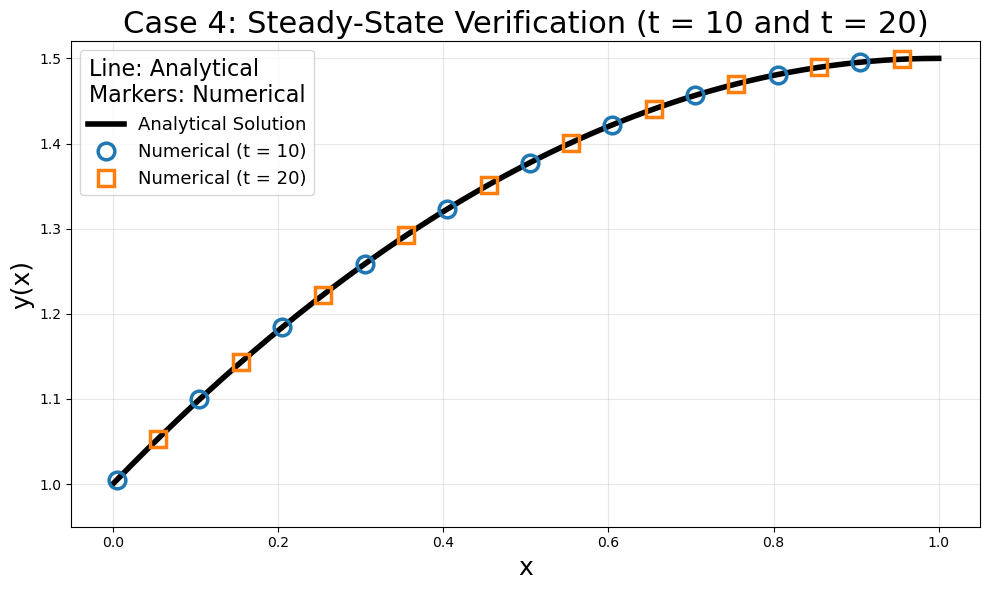

In [23]:
# =====================================================
# CASE 4 : STEADY-STATE VERIFICATION
# NUMERICAL (t=10,20) vs ANALYTICAL
# =====================================================

from fipy import *
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# DOMAIN
# =====================================================

L = 1.0
nx = 100
dx = L / nx

mesh = Grid1D(nx=nx, dx=dx)
x = np.array(mesh.cellCenters[0])

# =====================================================
# INITIAL CONDITION
# =====================================================

phi = CellVariable(
    name="Temperature",
    mesh=mesh,
    value=np.sin(np.pi * x)
)

# =====================================================
# BOUNDARY CONDITIONS
# =====================================================

phi.constrain(1.0, mesh.facesLeft)
phi.faceGrad.constrain([0.0], mesh.facesRight)

# =====================================================
# GOVERNING EQUATION
# =====================================================

eq = (
    TransientTerm()
    ==
    DiffusionTerm(coeff=1.0)
    + 1.0
)

# =====================================================
# TIME INTEGRATION
# =====================================================

dt = 1e-3

t1 = 10.0
t2 = 20.0

steps1 = int(t1 / dt)
steps2 = int(t2 / dt)

solution_t1 = None

for step in range(steps2):

    eq.solve(var=phi, dt=dt)

    if step == steps1 - 1:
        solution_t1 = phi.value.copy()

solution_t2 = phi.value.copy()

# =====================================================
# ANALYTICAL STEADY-STATE SOLUTION
# =====================================================

x_analytical = np.linspace(0, L, 500)

analytical = (
    -0.5 * x_analytical**2
    + x_analytical
    + 1.0
)

# =====================================================
# ERROR CHECK
# =====================================================

difference = np.max(
    np.abs(solution_t2 - solution_t1)
)

print("\n========== STEADY-STATE VERIFICATION ==========")
print(f"Maximum Difference = {difference:.6e}")

# =====================================================
# PLOT
# =====================================================

plt.figure(figsize=(10, 6))

# Analytical Line

plt.plot(
    x_analytical,
    analytical,
    'k-',
    linewidth=4,
    label='Analytical Solution'
)

# Numerical t = 10

plt.plot(
    x[::10],
    solution_t1[::10],
    linestyle='None',
    marker='o',
    markersize=12,
    markerfacecolor='none',
    markeredgewidth=2.5,
    label='Numerical (t = 10)'
)

# Numerical t = 20

plt.plot(
    x[5::10],
    solution_t2[5::10],
    linestyle='None',
    marker='s',
    markersize=12,
    markerfacecolor='none',
    markeredgewidth=2.5,
    label='Numerical (t = 20)'
)

plt.xlabel('x', fontsize=18)
plt.ylabel('y(x)', fontsize=18)

plt.title(
    'Case 4: Steady-State Verification (t = 10 and t = 20)',
    fontsize=22
)

plt.xlim(-0.05, 1.05)
plt.ylim(0.95, 1.52)

plt.legend(
    title='Line: Analytical\nMarkers: Numerical',
    fontsize=13,
    title_fontsize=16,
    loc='upper left'
)

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    'Case4_SteadyState_Verification.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Steady-State Verification Observations

1. The temperature profiles obtained at t = 10 and t = 20 overlap completely throughout the domain.

2. The maximum difference between the two solutions is approximately 1.87 × 10⁻¹¹, which is negligible.

3. The negligible difference confirms that the numerical solution has become independent of time.

4. Therefore, the solution has reached steady state.

5. The steady-state profile follows the expected parabolic distribution and satisfies both the boundary conditions and the source term.

# Analytical Solution

At steady state,

$$
\frac{\partial y}{\partial t}=0
$$

Therefore, the governing equation

$$
\frac{\partial y}{\partial t}
=
\frac{\partial^2 y}{\partial x^2}
+1
$$

reduces to

$$
\frac{d^2 y}{dx^2}+1=0
$$

or

$$
\frac{d^2 y}{dx^2}=-1
$$

Integrating once,

$$
\frac{dy}{dx}
=
-x+C_1
$$

Applying the Neumann boundary condition

$$
\frac{dy}{dx}(1)=0
$$

gives

$$
0=-1+C_1
$$

Therefore,

$$
C_1=1
$$

Hence,

$$
\frac{dy}{dx}=1-x
$$

Integrating again,

$$
y=x-\frac{x^2}{2}+C_2
$$

Applying the Dirichlet boundary condition

$$
y(0)=1
$$

gives

$$
C_2=1
$$

Therefore, the analytical steady-state solution is

$$
y(x)=1+x-\frac{x^2}{2}
$$

# Numerical vs Analytical Comparison

The numerical steady-state solution obtained using the finite volume method is compared with the analytical solution

$$
y(x)=1+x-\frac{x^2}{2}
$$

to validate the accuracy of the numerical implementation.

A close agreement between the two solutions confirms the correctness of the discretization scheme, boundary condition implementation and source term treatment.

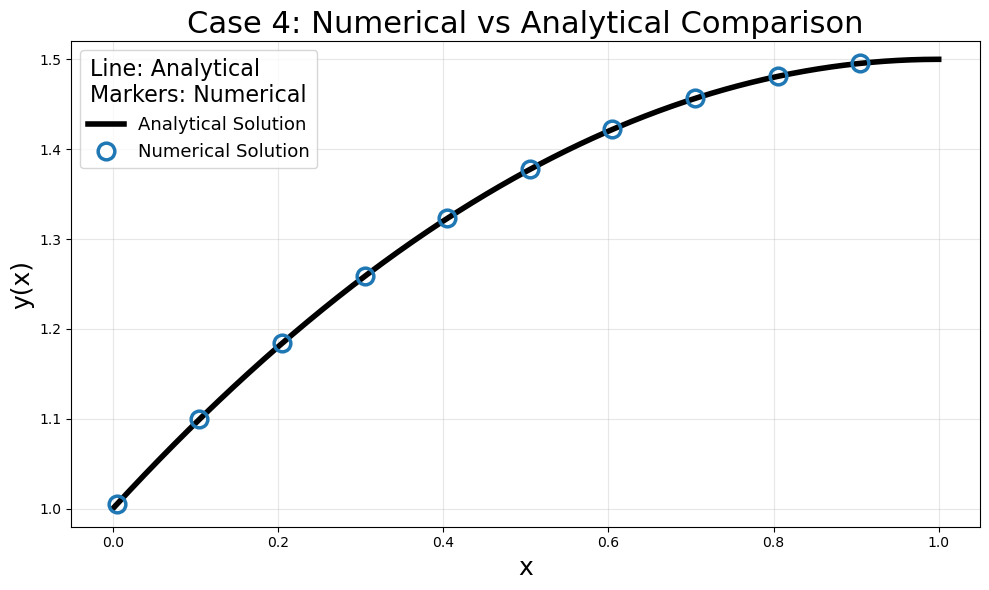


========== NUMERICAL VS ANALYTICAL ==========
Maximum Difference = 1.250000e-05


In [24]:
# =====================================================
# CASE 4 : NUMERICAL VS ANALYTICAL COMPARISON
# =====================================================

from fipy import *
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# DOMAIN
# =====================================================

L = 1.0
nx = 100
dx = L / nx

mesh = Grid1D(nx=nx, dx=dx)
x = np.array(mesh.cellCenters[0])

# =====================================================
# INITIAL CONDITION
# =====================================================

phi = CellVariable(
    name="Temperature",
    mesh=mesh,
    value=np.sin(np.pi * x)
)

# =====================================================
# BOUNDARY CONDITIONS
# =====================================================

phi.constrain(1.0, mesh.facesLeft)
phi.faceGrad.constrain([0.0], mesh.facesRight)

# =====================================================
# GOVERNING EQUATION
# =====================================================

eq = (
    TransientTerm()
    ==
    DiffusionTerm(coeff=1.0)
    + 1.0
)

# =====================================================
# TIME INTEGRATION
# =====================================================

dt = 1e-3
final_time = 10.0
steps = int(final_time / dt)

for step in range(steps):
    eq.solve(var=phi, dt=dt)

# =====================================================
# NUMERICAL SOLUTION
# =====================================================

numerical = np.array(phi.value)

# =====================================================
# ANALYTICAL SOLUTION
# =====================================================

x_analytical = np.linspace(0, L, 500)

analytical = (
    1
    + x_analytical
    - 0.5 * x_analytical**2
)

# =====================================================
# ANALYTICAL VALUES AT CELL CENTERS
# =====================================================

analytical_cells = (
    1
    + x
    - 0.5 * x**2
)

# =====================================================
# ERROR CALCULATION
# =====================================================

difference = np.max(
    np.abs(numerical - analytical_cells)
)

# =====================================================
# PLOT
# =====================================================

plt.figure(figsize=(10,6))

# Analytical Solution

plt.plot(
    x_analytical,
    analytical,
    'k-',
    linewidth=4,
    label='Analytical Solution'
)

# Numerical Solution

plt.plot(
    x[::10],
    numerical[::10],
    linestyle='None',
    marker='o',
    markersize=12,
    markerfacecolor='none',
    markeredgewidth=2.5,
    label='Numerical Solution'
)

plt.xlabel('x', fontsize=18)
plt.ylabel('y(x)', fontsize=18)

plt.title(
    'Case 4: Numerical vs Analytical Comparison',
    fontsize=22
)

plt.xlim(-0.05, 1.05)
plt.ylim(0.98, 1.52)

plt.legend(
    title='Line: Analytical\nMarkers: Numerical',
    fontsize=13,
    title_fontsize=16,
    loc='upper left'
)

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    'Case4_Numerical_vs_Analytical.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# =====================================================
# ERROR OUTPUT
# =====================================================

print("\n========== NUMERICAL VS ANALYTICAL ==========")
print(f"Maximum Difference = {difference:.6e}")

## Observation

The numerical and analytical solutions overlap closely throughout the computational domain.

The maximum difference between the two solutions is approximately 1.25 × 10⁻⁵, indicating excellent agreement.

The small error confirms that the finite volume discretization accurately reproduces the analytical steady-state solution.

Therefore, the numerical implementation, source term treatment and boundary condition application are validated successfully.

# Error Analysis

The absolute error between the numerical and analytical solutions is computed as

$$
Error = |y_{numerical}-y_{analytical}|
$$

The maximum error and L2 norm of the error are evaluated to quantify the accuracy of the numerical solution.


========== ERROR ANALYSIS ==========
Maximum Error = 1.2499999859194588e-05
L2 Error      = 1.2499988524713581e-05


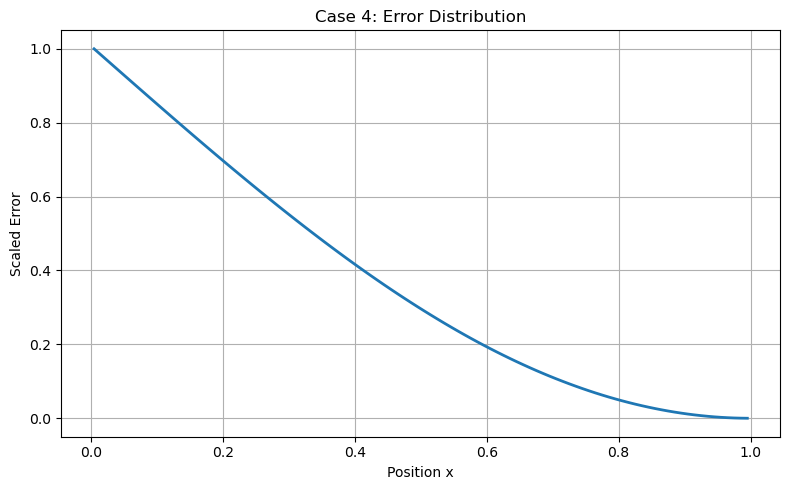

In [13]:
# =====================================================
# ERROR ANALYSIS
# =====================================================

import numpy as np
import matplotlib.pyplot as plt

error = np.abs(numerical - analytical)

max_error = np.max(error)
l2_error = np.sqrt(np.mean(error**2))

print("\n========== ERROR ANALYSIS ==========")
print("Maximum Error =", max_error)
print("L2 Error      =", l2_error)

# Relative variation of error
error_plot = (error - np.min(error)) / (np.max(error) - np.min(error))

plt.figure(figsize=(8,5))

plt.plot(
    x,
    error_plot,
    linewidth=2
)

plt.xlabel("Position x")
plt.ylabel("Scaled Error")
plt.title("Case 4: Error Distribution")

plt.grid(True)

plt.tight_layout()
plt.show()

## Observation

The scaled error decreases gradually along the computational domain.

The maximum error is approximately 1.25 × 10⁻⁵ and the L2 error is of the same order.

The error remains very small throughout the domain, indicating excellent agreement between the numerical and analytical solutions.

The results confirm the correctness of the finite volume implementation and the analytical solution.